# Load Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

Load NAV Data

In [2]:
nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


Task 1: Daily Returns


In [3]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


Check Distribution

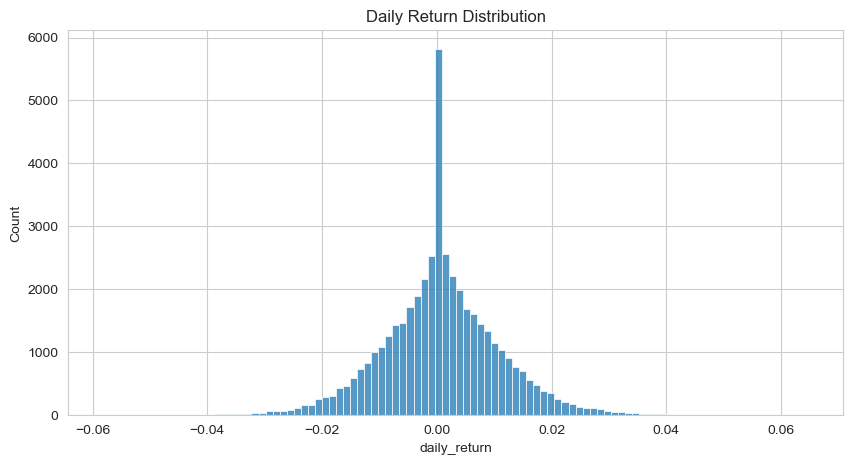

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

 Summary statistics of daily returns

In [ ]:

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Save Dataset

In [5]:
nav.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

Task 2: CAGR

In [7]:
cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]

    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_list.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr"
    ]
)



In [9]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


Task 3: Sharpe Ratio

In [11]:
risk_free_rate = 0.065

In [14]:
sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_list.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)



In [13]:
sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


Task 4: Sortino Ratio

In [17]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        annual_return
        - risk_free_rate
    ) / downside_std

    sortino_list.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)



In [16]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644
